### The Jameson Portfolio Optimizer 

This optimizer constructs an active small-cap equity portfolio benchmarked to the Russell 2000. 

#### This optimizer uses the following:
- Expected returns from the BUFC IA / JA / SA pitches (annualized)
- Covariance matrix (Ledoit–Wolf shrinkage)
- A global tracking error constraint vs. the Russell (via ETF sector proxies)
- Soft constraints on sector level deviations
- Hard allocation bands (ETFs vs. stocks, position caps, no leverage)

#### The goal: 
Find a portfolio that maximizes expected active return subject to a chosen tracking-error budget, while keeping exposures economically reasonable and diversified. This is a classic information-ratio maximization problem. 

#### Imports and Path Setup

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
SRC  = ROOT / "src"
DATA = ROOT / "data"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from companies import HOLDINGS_INFO, RUSSELL_SECTOR_WEIGHTS
from portfolio_optimizer import (
    OptimizerBands,
    optimize_quadratic_portfolio,
    run_te_sweep_frontier, 
)
from trade_sheet import build_trade_sheet_from_optimizer_result, TradePlanConfig, save_trade_sheet_csv

In [3]:
prices_path = DATA / "daily_prices.csv"
prices = pd.read_csv(prices_path, parse_dates=["date"]).set_index("date").sort_index()
prices.index = pd.to_datetime(prices.index)

universe = sorted(HOLDINGS_INFO.keys())

missing_cols = [t for t in universe if t not in prices.columns]
print("Price date range:", prices.index.min().date(), "->", prices.index.max().date())

assert not missing_cols, "daily_prices.csv missing tickers in HOLDINGS_INFO"

Price date range: 2025-01-02 -> 2026-01-23


#### Before Running the optimizer 
- [ ] Update HOLDINGS_INFO with desired companies/ETFS, expected returns, expense ratios (ETFs only). 
- [ ] Update RUSSELL_SECTOR_WEIGHTS with live sector weights and change comment to last updated date. 
- [ ] Double check that the daily_prices.csv has no null entries (above will throw an error if null entries exist)
- [ ] Define well thought out risk parameters (Tracking Error cap, ETF vs Stock allocation, position size limits, sector deviation penalty strength)

### Run optimizer

In [4]:
bands = OptimizerBands(
    etf_min=0.20, etf_max=0.35,
    stock_min=0.65, stock_max=0.8,
    max_weight_etf=0.09,
    max_weight_stock=0.07,
    sector_penalty_gamma=4.0, # ideal between 1.0-8.0
)

te_cap = 0.14   # annualized TE cap (try 0.08, 0.10, 0.12)

res = optimize_quadratic_portfolio(
    daily_prices_csv=prices_path,
    holdings_info=HOLDINGS_INFO,
    russell_sector_weights=RUSSELL_SECTOR_WEIGHTS,
    te_cap=te_cap,
    bands=bands,
    lookback_days=252,
    debug=False,   # flip True if you want the stage debug prints
)

assert res is not None, "Optimizer returned None (solver failure)."
print("Solved. TE:", res["te"], "ActiveRet(alpha·w):", res["active_return"], "IR:", res["ir"])


Solved. TE: 0.13250636138051167 ActiveRet(alpha·w): 0.08558374127037731 IR: 0.6458840192933145


If an error is thrown, the most likely cause is too tight of a tracking-error constraint AND/OR too tight of max_weight constraints or ETF/STOCK constraints. 

In [5]:
w = pd.Series(res["weights"]).sort_values(ascending=False)
w = w[w > 1e-6]

df_meta = pd.DataFrame.from_dict(HOLDINGS_INFO, orient="index")
df_meta.index.name = "Ticker"

summary = (
    pd.DataFrame({"Weight": w})
    .join(df_meta[["asset_type", "sector", "expected_return"]], how="left")
    .reset_index()
    .rename(columns={"index": "Ticker"})
)

print("Top holdings:")
display(summary.head(25))

etf_w = float(summary.loc[summary["asset_type"] == "index", "Weight"].sum())
stk_w = float(summary.loc[summary["asset_type"] != "index", "Weight"].sum())
print(f"ETF sleeve:   {etf_w:.1%}")
print(f"Stock sleeve: {stk_w:.1%}")
print(f"Total:        {(etf_w+stk_w):.1%}")


Top holdings:


,Ticker,Weight,asset_type,sector,expected_return
0,RSPF,0.090000,index,Financials,0.10
1,PSCI,0.090000,index,Industrials,0.10
2,STEP,0.070000,stock,Financials,0.20
3,EHC,0.070000,stock,Health Care,0.30
4,PRVA,0.070000,stock,Health Care,0.30
5,UAA,0.059946,stock,Consumer Discretionary,0.20
6,ENSG,0.059548,stock,Health Care,0.25
7,NXT,0.058245,stock,Information Technology,0.25
8,PSR,0.050487,index,Real Estate,0.10
9,ELLO,0.042843,stock,Utilities,0.20


ETF sleeve:   35.0%
Stock sleeve: 65.0%
Total:        100.0%


#### (Optional) Save trade sheet

In [6]:
cfg = TradePlanConfig(lot_size=1, min_trade_value=200.0, cash_buffer=0.02, cash_ticker="CASH")

snap_path   = DATA / "portfolio_snapshot.csv"

sheet = build_trade_sheet_from_optimizer_result(
    res=res,
    portfolio_snapshot_csv=snap_path,
    daily_prices_csv=prices_path,
    cfg=cfg,
)


=== TRADE SHEET (ordered by $ volume) ===
Ticker Action  TradeShares  Price  TradeValue  CurShares  NewShares
  PSCT   SELL    -2,627.00  61.48 -161,515.05   2,865.00     238.00
  PRVA    BUY     3,831.00  23.94   91,714.14       0.00   3,831.00
  KBWR   SELL    -1,226.00  64.83  -79,487.71   1,226.00       0.00
   UAA    BUY    12,368.00   6.35   78,536.80       0.00  12,368.00
  RSPF    BUY       771.00  77.83   60,008.01     744.00   1,515.00
  PATK   SELL      -462.00 128.28  -59,265.36     462.00       0.00
  ELLO    BUY     2,116.00  26.52   56,116.32       0.00   2,116.00
   TTC    BUY       584.00  89.79   52,437.36       0.00     584.00
   EHC    BUY       507.00  98.40   49,888.80     425.00     932.00
  PSCH   SELL    -1,058.00  45.17  -47,791.55   1,680.00     622.00
  ACHR    BUY     5,087.00   8.61   43,799.07       0.00   5,087.00
  CASH   SELL   -39,385.00   1.00  -39,385.00  66,121.67  26,736.67
  PSCI   SELL      -219.00 165.07  -36,150.09     933.00     714.00
  LAS

#### Post-Hoc analysis 

In [7]:
from sklearn.linear_model import LinearRegression

tickers = res["tickers"]
w_b = pd.Series(0.0, index=tickers)

# benchmark is ETF proxy weights by sector (already embedded in res as benchmark_sector_weights)
b_sec = pd.Series(res["benchmark_sector_weights"])
sector_to_etf = {
    meta["sector"]: t
    for t, meta in HOLDINGS_INFO.items()
    if meta.get("asset_type") == "index" and meta.get("sector") is not None
}
for sec, bw in b_sec.items():
    etf = sector_to_etf.get(sec)
    if etf in w_b.index:
        w_b.loc[etf] += float(bw)
w_b = w_b / w_b.sum()

# returns matrix
px = prices[tickers].ffill()
R = px.pct_change().dropna()

# align weights
w_vec = pd.Series(res["weights"]).reindex(tickers).fillna(0.0).to_numpy()
wb_vec = w_b.reindex(tickers).fillna(0.0).to_numpy()

rp = R.to_numpy() @ w_vec
rb = R.to_numpy() @ wb_vec
active = rp - rb

ann_active_mean = float(np.mean(active) * 252.0)
te = float(np.std(active, ddof=1) * np.sqrt(252.0))

# beta of portfolio to benchmark
var_b = float(np.var(rb, ddof=1))
beta = float(np.cov(rp, rb, ddof=1)[0, 1] / var_b) if var_b > 1e-12 else float("nan")

# residual TE from regression rp ~ a + beta*rb
if np.isfinite(beta):
    X = rb.reshape(-1, 1)
    reg = LinearRegression().fit(X, rp)
    resid = rp - reg.predict(X)
    resid_te = float(np.std(resid, ddof=1) * np.sqrt(252.0))
else:
    resid_te = float("nan")

print("REALIZED (ex-post) active mean (ann):", f"{ann_active_mean:.2%}")
print("REALIZED tracking error (ann):       ", f"{te:.2%}")
print("Beta to ETF-benchmark:               ", f"{beta:.3f}")
print("Residual TE (ann):                   ", f"{resid_te:.2%}")


REALIZED (ex-post) active mean (ann): 15.19%
REALIZED tracking error (ann):        7.24%
Beta to ETF-benchmark:                1.057
Residual TE (ann):                    7.15%


Interpretation: 
- TE tells you total active risk vs benchmark.
- Beta tells you how much of your portfolio behaves like the ETF benchmark.
- resid_te tells you how much “idiosyncratic” tracking error remains after stripping the benchmark exposure.

In [8]:
sector_map = {t: HOLDINGS_INFO[t].get("sector") for t in tickers}
ticker_to_col = {t: j for j, t in enumerate(tickers)}

rows = []
variances = []

for sec, bw in b_sec.items():
    bench_etf = sector_to_etf.get(sec)
    if bench_etf is None or bench_etf not in ticker_to_col:
        continue

    idxs = [ticker_to_col[t] for t in tickers if sector_map.get(t) == sec]
    if not idxs:
        continue

    # sector contribution
    Rp = R.to_numpy()[:, idxs] @ w_vec[idxs]
    Rb = float(bw) * R.to_numpy()[:, ticker_to_col[bench_etf]]

    active_sec = Rp - Rb
    te_s = float(np.std(active_sec, ddof=1) * np.sqrt(252.0))
    var_s = float(np.var(active_sec, ddof=1))
    variances.append(var_s)

    port_w_sec = float(np.sum([w.get(t, 0.0) for t in w.index if sector_map.get(t) == sec]))

    rows.append({
        "Sector": sec,
        "Proxy": bench_etf,
        "BenchW": float(bw),
        "PortW": port_w_sec,
        "ActiveContribTE": te_s,
    })

sector_te = pd.DataFrame(rows)
if sector_te.empty:
    print("No sector TE report (missing proxies or sector mapping).")
else:
    total_var = float(np.sum(variances)) if np.sum(variances) > 0 else 1.0
    sector_te["VarShare"] = [float(v/total_var) for v in variances]
    sector_te = sector_te.sort_values(["VarShare", "ActiveContribTE"], ascending=False).reset_index(drop=True)
    display(sector_te)


,Sector,Proxy,BenchW,PortW,ActiveContribTE,VarShare
0,Health Care,PSCH,0.195537,0.220991,0.039155,0.255240
1,Information Technology,PSCT,0.128689,0.138349,0.038184,0.242732
2,Consumer Discretionary,PSCC,0.113463,0.123542,0.037230,0.230753
3,Industrials,PSCI,0.188549,0.191678,0.027063,0.121935
4,Utilities,PSCU,0.035562,0.042843,0.020889,0.072647
5,Financials,RSPF,0.179685,0.160000,0.020854,0.072399
6,Materials,PSCM,0.042027,0.029275,0.003478,0.002014
7,Energy,RSPG,0.054959,0.042835,0.003264,0.001774
8,Real Estate,PSR,0.061529,0.050487,0.001744,0.000507


From this table, we can see: 
- which sectors dominate active risk (VarShare)
- which sectors have the biggest active-risk contribution (ActiveContribTE)
- how far the sector weights are from benchmark (PortW vs BenchW)

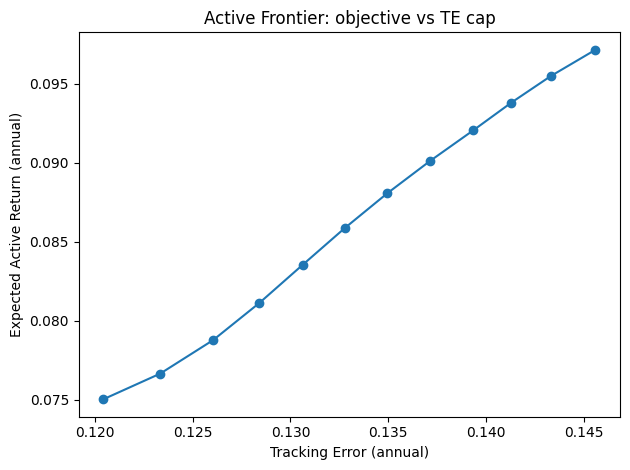

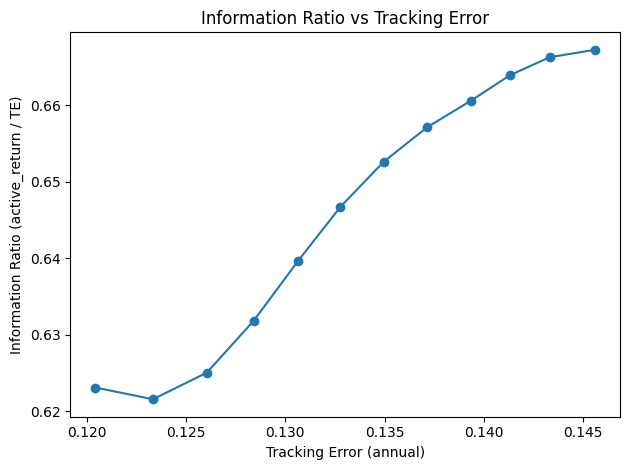

,te_cap,te,active_return,ir,status
45,0.146939,0.137156,0.090132,0.657146,ok
46,0.150204,0.139352,0.092056,0.660601,ok
47,0.153469,0.141312,0.093820,0.663924,ok
48,0.156735,0.143318,0.095491,0.666286,ok
49,0.160000,0.145607,0.097158,0.667260,ok


Best exists? True
Best TE: 0.14560730796217936 Best IR: 0.6672601647762153 Best ActiveRet: 0.09715795630346492


In [9]:
res_sweep = run_te_sweep_frontier(
    daily_prices_csv=prices_path,
    holdings_info=HOLDINGS_INFO,
    russell_sector_weights=RUSSELL_SECTOR_WEIGHTS,
    bands=bands,
    te_min=0.00,
    te_max=0.16,
    te_points=50,
    lookback_days=252,
    debug=False,
    mosek_log=False,
    plot=True,
)

frontier = res_sweep["frontier"]
best = res_sweep["best"]

display(frontier.tail())
print("Best exists?", best is not None)
if best:
    print("Best TE:", best["te"], "Best IR:", best["ir"], "Best ActiveRet:", best["active_return"])